# Aprendizaje por Refuerzo

## Introducción



  *   Con el aprendizaje supervisado se aprende de la entrada/salida.
  *   Con el aprendizaje por refuerzo (RL) se aprende desde la propia experiencia considerando sus éxitos y fallas.
  *   En RL un agente interactúa con el mundo y recibe recompensas que reflejan lo bien que lo ha hecho.
  *   Ejemplo: Imagine un juega un juego, del cual usted no conoce las reglas, y después de varios movimientos el árbitro te indica que perdiste.
  * En algunos problemas es más fácil proveer una señal de recompensa por una acción que una etiqueta.
  * Una función que retorna una recompensa dada una acción, puede ser fácil de definir y programar (Ej, ajedrez y carro autónomo).


## Sobre el Aprendizaje por Refuerzo

> "Un proceso de ensayo y error basado en recompensas, en el que un sistema aprende a interactuar con un entorno complejo para lograr resultados gratificantes, se conoce en el lenguaje del aprendizaje automático como aprendizaje por refuerzo."

Fuente: *Neural Networks and Deep Learning*, por Charu C. Aggarwal. Segunda edición, 2023.

Logros del Aprendizaje por Refuerzo:
  * Los sistemas de aprendizaje profundo han sido entrenados para jugar videojuegos mediante aprendizaje por refuerzo.
  * DeepMind ha entrenado un algoritmo de aprendizaje por refuerzo profundo, AlphaZero, para jugar al ajedrez, al shogi y al Go.
  * En los últimos años, el aprendizaje profundo por refuerzo se ha usado en los coches autónomos.
  * La búsqueda de la creación de robots que aprenden por sí mismo es una tarea del aprendizaje por refuerzo.

Fuente: *Neural Networks and Deep Learning*, por Charu C. Aggarwal. Segunda edición, 2023.

### Ilustración de las aplicaciones del Aprendizaje por Refuerzo

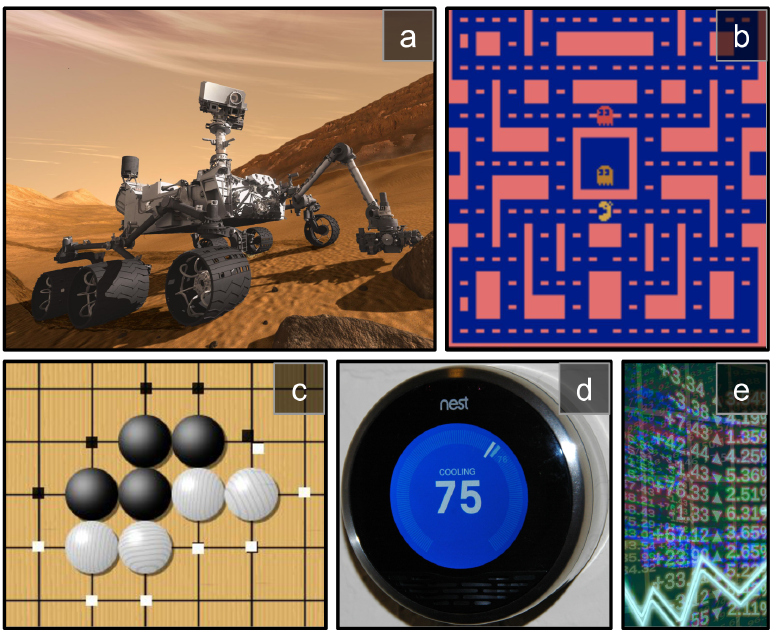

Aplicaciones de RL:  a) Robótica, b) Juegos como PacMan, c) Juegos como Go, d) Termostatos Inteligentes, e) Operaciones automáticas en la Bolsa.

Fuente: *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* por Aurélien Géron. O’Reilly, 2023.  

## El Marco Básico del Aprendizaje por Refuerzo

*   Uno de los  objetivos del aprendizaje por refuerzo es el asignar valores, a cada una de las acciones que puede hacer un agente en un estado.
*   El agente puede entonces escoger la acción a ejecutar con esos valores.
*   La idea es que un agente en un **estado** dado, obtiene el valor de las acciones, y luego toma **acción**. Unav vez tomada la **acción**, entonces recibe una **recompensa**.
*   El proceso de generar una secuencia de estados, acciones y recompensas se denomina Proceso de Decisión de Markov (MDP).
*   Un MDP puede representarse como una secuencia de acciones, estados y recompensas de la siguiente manera: $<s(s_0,a_0,r_0), (s_1,a_1,r_1), \dots, (s_N,a_N,r_N) >$.


### Ilustración del Marco Básico de RL

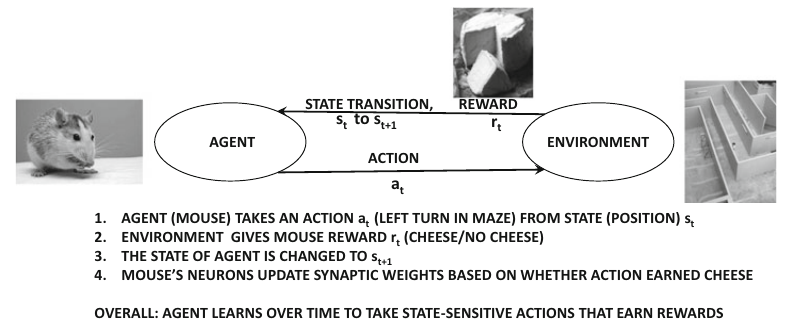

Fuente:  *Neural Networks and Deep Learning*, por Charu C. Aggarwal. Segunda edición, 2023.

## Configuración

* Se importan las librerías básicas

In [1]:
import sys
import os
import tf_keras

* Se importa la librería Tensor Flow

In [2]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

* Se importa Matplotlib y se configura

In [3]:
import matplotlib.animation
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

* Se verifica que se esté usando GPU

In [4]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

## Búsqueda de Políticas

* El algoritmo que utiliza un agente de software para determinar sus acciones se denomina su política.
* La política podría ser una red neuronal que recibe como entrada observaciones del mundo y retorna la acción a realizar.

### Ilustruación de Búsqueda de Políticas

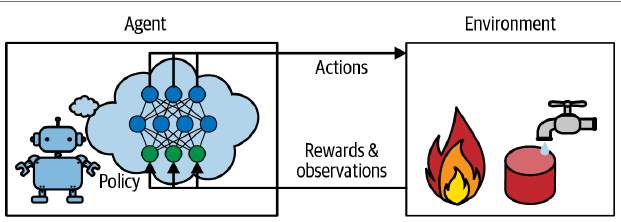

Fuente: *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* por Aurélien Géron. O’Reilly, 2023.

### Ilustración de Espacio de Políticas

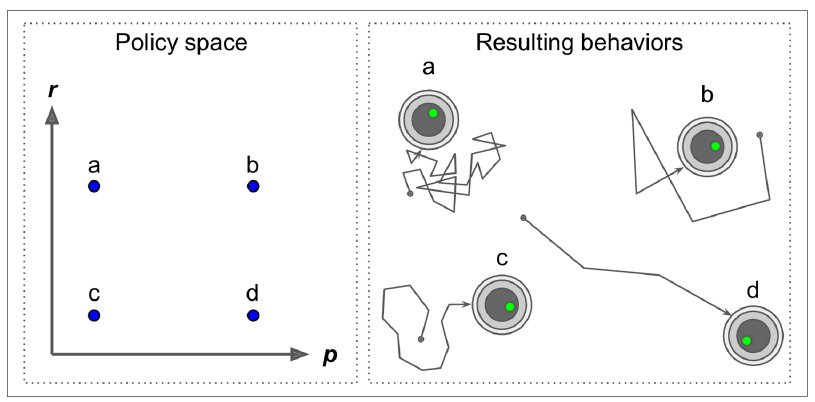

Fuente: *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* por Aurélien Géron. O’Reilly, 2023.

## Introducción a OpenAI Gym

* En RL para que el agente pueda aprender se necesita un ambiente donde va a aprender.
* Ejemplo: Si un agente va a aprender a jugar un Juego de Atari, se necesita el simulador de Atari.
* Como aprender en el mundo real es costoso, se necesita simuladores del mundo real.
* OpenAI es una librería que ofrece varios ambientes de simulación, para entrenar agentes.
* OpenAI cedió el mantenimiento de la librería a la Fundación Farama (ver el  [anuncio](https://farama.org/Announcing-The-Farama-Foundation)).
* La librería ahora se llama Gymnasium.

* Se descarga la librería

In [5]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

if IS_COLAB or IS_KAGGLE:
    %pip uninstall -y gym  # to avoid any conflicts with Gymnasium
    %pip install -q box2d

Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 56.0 MB/s eta 0:00:00


* Se importa la librería Gymnasium que sirve para desarrollar agentes con RL y probar algoritmos de RL.
* Se importa el ambiente de trabajo para RL Cart-Pole.
* El Cart-Pole es un MDP de estado continuo, acción discreta o continua con transiciones deterministas.
* El objetivo es mantener el poste en posición vertical y el carro dentro de la vía el mayor tiempo posible.
* El carro puede ser acelerado a la izquierda o derecha para mantener el poste.

In [6]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="rgb_array")

### Ilustración del Ambiente Cart-Pole

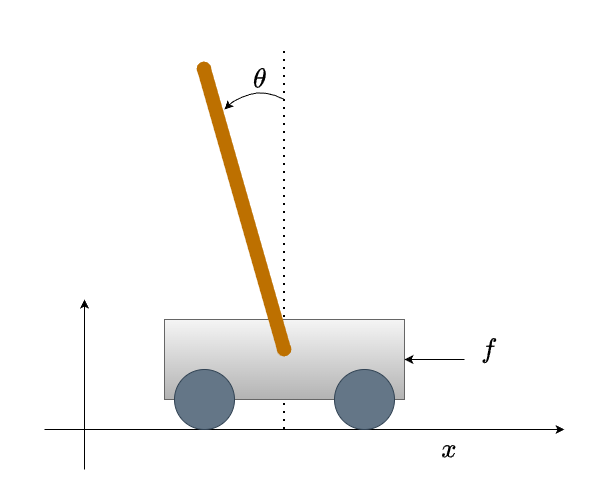

Fuente: [The Cart-Pole Simulator](https://teazrq.github.io/stat546/notes/rl/cartpole.html)

* Se obtiene en diccionario, que llamamos *envs*, con los ambientes disponibles.

In [7]:
# extra code – shows the first few environments
envs = gym.envs.registry
sorted(envs.keys())[:5] + ["..."]

['Acrobot-v1', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', '...']

* Se muestra las características del ambiente Cart-Pole

In [8]:
# extra code – shows the specification for the CartPole-v1 environment
envs["CartPole-v1"]

EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')

* Se reinicia el ambiente con el método reset()
* El arreglo *obs* contiene cuatro valores reales que representan:
  * obs[0]: la posición horizontal del carrito (0.0 = centro)
  * obs[1]: su velocidad (positivo significa derecha)
  * obs[2]: el ángulo del poste (0.0 = vertical)
  * obs[3]: su velocidad angular (positivo significa sentido horario)

In [9]:
obs, info = env.reset(seed=42)
obs

array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32)

* El ambiente puede ser visualizado con el método *render()*

In [10]:
img = env.render()
img.shape  # height, width, channels (3 = Red, Green, Blue)

(400, 600, 3)

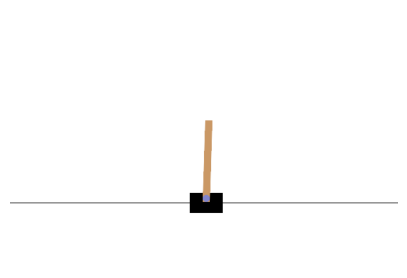

In [11]:
# extra code – creates a little function to render and plot an environment

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

* Le preguntamos al ambiente las acciones que se pueden ejecutar.

In [12]:
env.action_space

Discrete(2)

* Hay dos posibles acciones, mover a la izquierda (0) o a la derecha (1).
* Como el poste está inclinado ligeramente a la derecha, movemos a la derecha.

In [13]:
action = 1
obs, reward, done, truncated, info = env.step(action)
obs

array([ 0.02727336,  0.18847767,  0.03625453, -0.26141977], dtype=float32)

* Estos valores indican que:
  * El poste está ligeramente a la (obs[0] > 0)
  * El carro se mueve a la derecha (obs[1] > 0)
  * El ángulo del poste es ligeramente a la derecha (obs[2] > 0)
  * El poste tiene velocidad angular a la izquierda (obs[3] < 0)

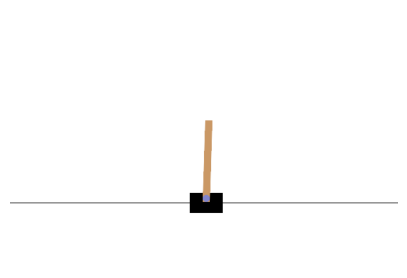

In [14]:
plot_environment(env)
plt.show()

* El ambiente indica la recompensa que ha ganado el agente

In [15]:
reward

1.0

* Cuando el juego finaliza, se tiene que `done=True`
* En este caso, aún no ha terminado el juego

In [16]:
done

False

* Cuando un agente se sale del juego o cuando se interrumpe su ejecución se tiene que `truncated=True`

In [17]:
truncated

False

* Se tiene que *info* da información sobre el ambiente del juego

In [18]:
info

{}

* La secuencia de acciones de un agente desde su inicio hasta que el ambiente se ha termindo o ha sido truncado, se llama **episodio**
* Una vez finalizado un episodio, se reinicia el agente

In [19]:
if done or truncated:
    obs, info = env.reset()

## Agente con una política específica dada

* Se diseña una política específica para el agente en CartPole.
* El agente acelere hacia la izquierda cuando el poste se incline hacia la izquierda.
* El agente acelera hacia la derecha cuando el poste se incline hacia la derecha.
* Se ejecuta esta política para ver las recompensas que se obtiene en 500 episodios.

In [20]:
def basic_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

totals = []
for episode in range(500):
    episode_rewards = 0
    obs, info = env.reset(seed=episode)
    for step in range(200):
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        episode_rewards += reward
        if done or truncated:
            break

    totals.append(episode_rewards)

* Se muestra los resultados los resultados obtenidos de esta política.

In [21]:
import numpy as np

np.mean(totals), np.std(totals), min(totals), max(totals)

(np.float64(41.698), np.float64(8.389445512070509), 24.0, 63.0)

* Estos resultados indican que con esta política básica, lo máximo que se pudo mantener el poste en el carro fue 63 pasos.

* Se muestra la simulación de un episodio.

In [22]:
# extra code – this cell displays an animation of one episode

def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = matplotlib.animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

def show_one_episode(policy, n_max_steps=200, seed=42):
    frames = []
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    np.random.seed(seed)
    obs, info = env.reset(seed=seed)
    for step in range(n_max_steps):
        frames.append(env.render())
        action = policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break
    env.close()
    return plot_animation(frames)

show_one_episode(basic_policy)

## Políticas de Redes Neuronales

* Se va crear una política de red neuronal.
*  Esta red neuronal recibirá una observación como entrada y generará la acción a ejecutar.
* La red computa la probabilidad de cada acción, y escoge con mayor probabilidad, la acción con mayor valor.
* En este caso de CartPole las acciones es ir a la derecha y a la izquierda.
* Debido a esto se tiene una neurona de salida, para obtener la probabilidad $p$ de ir a la izquierda (o la derecha $1-p$).
* Si la salida de la neurona es 0.8, entonces con 80% de probabilidad el agente escogerá  ir a la izquierda y 20% ir a la izquierda.
* No se escoge siempre la acción con mayor probabilidad, porque se quiere tener un balance entre exploración/explotación.

### Ilustración de Políticas de Redes Neuronales

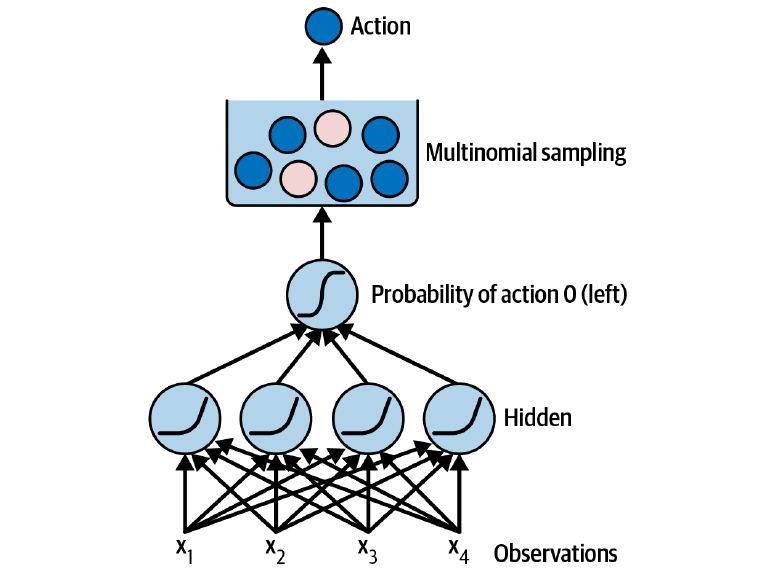

Fuente: *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* por Aurélien Géron. O’Reilly, 2023.

* Se construye una política básica de red neuronal usando Keras:

In [23]:
import tensorflow as tf

tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU

model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

* Se crea una función con la política del agente, que utilice la red neuronal para obtener la probabilidad de moverse a la izquierda.
* Luego se usa esta política para ejecutar un episodio.

In [24]:
# extra code – a function that creates an animation for a given policy model

def pg_policy(obs):
    left_proba = model.predict(obs[np.newaxis], verbose=0)[0][0]
    return int(np.random.rand() > left_proba)

np.random.seed(42)
show_one_episode(pg_policy)

* Ya se tiene una política de red neuronal que tomará observaciones y generará probabilidades de acción.
* Esta política, como muestra la animación, no trabaja muy bien.
* Ahora falta ver **como se entrena esta red**, para obtener un mejor rendimiento.

##  Evaluación de acciones: El Problema de la Asignación de Créditos

* Se quiere saber cuales acciones del agente se deben recompensar.
* Por ejemplo, si el agente logra mantener el equilibrio en el poste durante 100 pasos, ¿cómo puede saber cuáles de las 100 acciones que realizó fueron buenas y cuáles fueron malas?
* Suponiendo que se tiene durante la ejecución de un agente se obtiene una recompensa X ¿Cómo se reparten es recompensa con las acciones? Esto es lo que se llama el Problema de la Asignación de Créditos.
* La idea es evaluar una acción en función de la suma de todas las recompensas posteriores, aplicando generalmente un factor de descuento, $\gamma$ (gamma), en cada paso.
* Suponga que el agente de abajo hace tres movimientos a la derecha, en el primer movimiento gana 10, en el segundo gana cero y en tercero gana -50, y suponga un factor de descuento $\gamma = 0.8$.
* Entonces, la primera acción tienen una retorno de recompensa calculado como $= \gamma 0 \times 10 + \gamma 1 \times 0 +  \gamma 2 \times (-50) = 10  + 0 – 32 = 22$.

### Ilustración del cálculo del retorno de una acción con la suma de las recompensas futuras descontadas

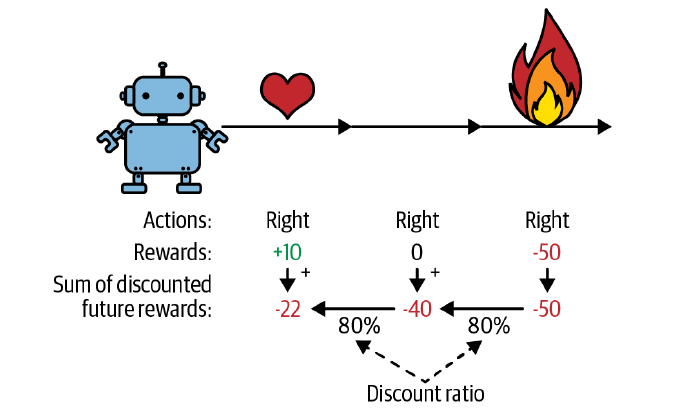

Fuente: Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow por Aurélien Géron. O’Reilly, 2023.

## Gradientes de Políticas

* Los algoritmos de *gradientes de políticas* optimizan los parámetros de una política siguiendo los gradientes hacia recompensas más altas.
* A continuación presentamos el Algoritmo de Refuerzo, que consiste en los siguientes pasos:
  1.   Se juega varias veces con la política de la red neuronal y, en cada paso, se
calcula los gradientes pero no aplica estos gradientes todavía.
  2.   Se ejecutan varios episodios, luego se calcula el retorno de recompensa  de cada acción utilizando el método descrito en la sección anterior.
  3.   Si una acción tiene un retorno de recompensa positivo, entonces  significa que probablemente fue buena, y se deben aplicar los gradientes calculados previamente para aumentar aún más la probabilidad de que se elija en el futuro. En caso contrario,  si la acción es negativa, significa que probablemente fue mala, y se deben aplicar los gradientes opuestos para disminuir la probabilidad de que se elija en el futuro.
  4. Se calcula el promedio de los vectores gradiente resultantes y se usa para realizar un paso de descenso de gradiente.

In [25]:
def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape:
        left_proba = model(obs[np.newaxis])
        action = (tf.random.uniform([1, 1]) > left_proba)
        y_target = tf.constant([[1.]]) - tf.cast(action, tf.float32)
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))

    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, truncated, info = env.step(int(action))
    return obs, reward, done, truncated, grads

* Si el valor de $\texttt{left_proba}$ es alto, entonces la acción debe ser probablemente falsa.
* Función para reproducir varios episodios, usando la función $\texttt{play_one_step}$, devolviendo todas las recompensas y gradientes para cada episodio y cada paso.
* Esta función retorna una lista de listas de recompensas: una lista de recompensas por episodio, que contiene una recompensa por paso.

In [26]:
def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = play_one_step(
                env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

* El algoritmo de la gradientes de políticas, ejecutará  $\texttt{play_multiple_episodes()}$ para jugar varias veces.
* Se revisan las recompensas para descontarlas y normalizarlas.
* La función $\texttt{discount_rewards}$ hace descuento de las recompensas.
* La función $\texttt{discount_and_normalize_rewards}$ hace descuento de las recompensas y las normaliza.

In [27]:
def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [discount_rewards(rewards, discount_factor)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

* Ejemplo de como funcionan las recompensas con descuentos.
* Suponemos que se hacen tres acciones, la primera tiene una recompensa de cero, la segundo de 0, y la tercera de -10.
* Se tiene como factor de descuento 0.8
* Como la última acción (la tercera) tiene una recompensa de -50 entonces se mantiene sin descuentos
* Como la segunda acción tiene una recompensa de -40, entonces la recompensa con descuento es $0.8* (-50) + 0 = 20$
* Como la tercera acción tiene una recompensa de 10, entonces la recompensa con descuento, es $0.8*(-40) + 10 = 22$

In [28]:
discount_rewards([10, 0, -50], discount_factor=0.8)

array([-22, -40, -50])

Para normalizar todas las recompensas con descuento en todos los episodios se hacen los siguientes pasos:
1. Se calculamos la media y la desviación estándar de todas las recompensas con descuento.
2. Se resta la media a cada recompensa con descuento.
3. Se divide por la desviación estándar.

In [29]:
discount_and_normalize_rewards([[10, 0, -50], [10, 20]],
                               discount_factor=0.8)

[array([-0.28435071, -0.86597718, -1.18910299]),
 array([1.26665318, 1.0727777 ])]

* Se configuran los parámetros para el entrenamietno de la red.
* Son 150 iteraciones de entenamiento.
* Se juegan 10 episodios por iteración.
* Cada episodio tiene 200 pasos.
* El factor de descuento 0.95.

In [30]:
n_iterations = 100
n_episodes_per_update = 10
n_max_steps = 200
discount_factor = 0.95

* Se vuelve a crear la red neural.
* Se resetean los parámetros.

In [31]:
# extra code – let's create the neural net and reset the environment, for
#              reproducibility

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

obs, info = env.reset(seed=42)

* Se necesita un optimizador y una función de pérdida.
* Se usa como optimizador Nadam.
* Se usa como función de pérdida
* Se usará la función de pérdida de entropía cruzada binaria porque estamos entrenando un clasificador binario.
* Es un clasificador binario porque se debe tomar la acción de mover a la derecha o izquierda.

In [32]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.binary_crossentropy

* Se ejecuta y se construye el entrenamiento.

In [33]:
for iteration in range(n_iterations):
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)

    # extra code – displays some debug info during training
    total_rewards = sum(map(sum, all_rewards))
    print(f"\rIteration: {iteration + 1}/{n_iterations},"
          f" mean rewards: {total_rewards / n_episodes_per_update:.1f}", end="")

    all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                       discount_factor)
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
                 for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)

    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

Iteration: 100/100, mean rewards: 186.0

* Se muestra la animación los gradientes de políticas

In [34]:
# extra code – displays the animation
np.random.seed(42)
show_one_episode(pg_policy)

## Procesos de decisión de Markov (Markov Decision Processes - MDP)

* Los MDP son procesos estocásticos sin memoria.
* Se pasa de un estado $s$ a un estado $s'$, se denota como $(s, s')$, con una probabilidad fija.
* La probabilidad solo depende de $s$ y $s'$.
* Antes de analizar los MDP, se explica la cadena de Markov.

## Ilustración de una cadena de Markov.

* Los valores en los lados, son la probabilidad de pasar de un estado a otro.
* Si un agente está en el estado $s_0$, hay 70\% de probabilidades de que permanezca en este estado, 10% que vaya a $S_3$ y 20\% que siga a $S_1$.
* Si el agente pasa a $S_1$, hay 90\% de probabilidad de que vaya a $S_2$ y 10\% de probabilidad que vaya a $S_3$.
* Si el agente pasa al estado $S_3$, entonces de allí no sale, a este tipo de estados se les llama terminal.

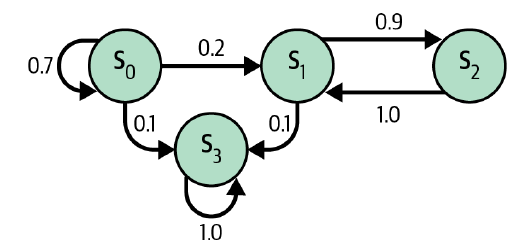

Fuente: Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow por Aurélien Géron. O’Reilly, 2023.

## Sobre los Procesos de Decisión de Markov

* En los Procesos de Decisión de Markov, se tiene un agente que estando en un estado toma una acción, y esta se efectúa con cierta probabilidad.
* Se explica el MDP con el agente de la figura.
* Si el agente estando en $s_0$, aplica la acción $a_1$, entonces se mantiene en $s_0$.
* Si el agente estando en $s_0$, aplica la acción $a_0$, entonces con 70\% de probabilidad llega de nuevo al estado $s_0$ obteniendo una recompensa de 10, y con 30\% de probabilidad llega a $s_1$.
* Si el agente estando $s_0$, aplica la acción $a_2$, entonces con 80\% de probabilidad llega de nuevo a $s_0$ y con 20\% llega al estado $s_1$.
* Supongamos que llega el agente de $s_0$, llega a $s_1$, aplicando la acción $a_1$.
* Luego, estando en $s_2$, el agente aplica la acción $a_2$ entonces con 100\% de probabilidad llega a $s_2$, obteniendo una recompensa negativa de -50.
* De esta manera trabaja un agente MDP.

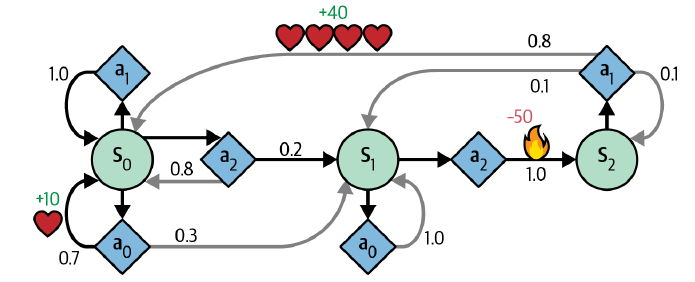

Fuente: Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow por Aurélien Géron. O’Reilly, 2023.

* La ecuación de Bellman permite estimar el valor óptimo de cada estado.
* Se interpreta la ecuación de Bellman como que si el agente actúa de forma óptima, entonces el valor óptimo del estado actual es igual a la recompensa, que obtendrá en promedio después de realizar una acción óptima, más el valor óptimo esperado de todos los posibles estados subsiguientes a los que esta acción puede conducir.
* La ecuación de Bellman es como sigue:

$$
V^*(s) = \max_a  \sum_{s’} T(s,a,s’)[R(s,a,s’)+\gamma \cdot V^*(s’)] \text{ para todo } s
$$

Donde:
* $T(s,a,s’)$: Probabilidad de la transción desde un estado $s$ hasta un estado $s’$. Por ejemplo, en la figura anterior $T(s_0,a_2,s_1) = 0.2$.
* $R(s,a,s’)$: Recompensa que el agente recibe al ir desde el estado s hasta el estado s’. Por ejemplo, en la figura anterior $R(s_2, a_1, s_0)  = 40$.
* $\gamma$ es el factor de descuento.

## Valores Q

* Bellman encontró un algoritmo para estimar los valores óptimos de estado-acción, denominados valores Q (valores de calidad).
* Sea $Q^*(s, a)$ el valor óptimo del par estado-acción $(s, a)$.
* Se tiene que $Q^*(s, a)$  es la suma de las recompensas futuras descontadas que el agente puede esperar en promedio después de alcanzar el estado $s$ y elegir la acción $a$
* En el cálculo de $Q^*(s, a)$, suponemos que es que el agente actúa de forma óptima después de ejecutar la acción $a$.
* El algoritmo *Iteración Q-value* para calcular los Q valores.
* Inicialmente los Q valores son todos ceros.
* El algoritmo *Iteración Q-value* es dado por la siguiente ecuación:
$$
Q_{k+1}(s,a) \leftarrow \sum_{s’} T(s,a,s’) [R(s,a,s’) + \gamma \cdot \max_a’ Q_k(s’,a’)] \text{ para todo } (s,a)
$$
* Donde $k$ es la iteración del algoritmo.
* El algoritmo *Iteración Q-value* encuentra el valor óptimo después de suficientes iteraciones.
* Una vez obtenidos los valores Q se puede determinar la política óptima $\pi^*(s)$ para el agente.
* Una política  óptima  le indica al agente que acción tomar, dependiendo del estado en que esté.
* Cuando un agente esté en un estado $s$, debe escoger la acción la acción con mayor valor Q, para ese estado, esto es:

$$
\pi^*(s) = \arg\max_{a} Q^*(s, a)
$$

* Se aplica ese algoritmo a la Figura MDP anterior.
* Primero se define el MDP según la Figura MDP anterior.
* La notación es como sigue: Para el estado $s_0$ se tiene que si se aplica la acción $a_0$ se llega a $s_0$ con 70\% de probabilidad al estado $a_0$, y con 30\% al estado $s_1$, esto se representa con el vector $[0.7, 0.3, 0.0]$.
* La recompensas de $(s_0 , a_0 , s_0)$ es 10, la recompensa de $(s_0 , a_0 , s_2)$ es 0, y no se puede llegar a $s_2$  desde $s_0$, por lo que la recompensa  $(s_0 , a_0 , s_1)$  es cero, esto se representa con el vector $[10, 0, 0]$.

In [35]:
transition_probabilities = [  # shape=[s, a, s']
    [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
    [[0.0, 1.0, 0.0], None, [0.0, 0.0, 1.0]],
    [None, [0.8, 0.1, 0.1], None]
]
rewards = [  # shape=[s, a, s']
    [[+10, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
    [[0, 0, 0], [+40, 0, 0], [0, 0, 0]]
]
possible_actions = [[0, 1, 2], [0, 2], [1]]

* Para $(s_2, a_1, s_0)$, se tiene un probabilidad de 80\%.

In [36]:
transition_probabilities[2][1][0]

0.8

* Para $(s_2, a_1, s_0)$, se tiene una recompensa de 40.

In [37]:
rewards[2][1][0]

40

## Aplicando el Algoritmo *Iteración Q-value*

* Se inicializa todos los valores a Q a cero, y los de las acciones que no existen a -∞.

In [38]:
Q_values = np.full((3, 3), -np.inf)  # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0  # for all possible actions

* Se va aplicar el algoritmo *Iteración Q-value* por 50 iteraciones.
* Se va a obtener los valores Q para todos los estados y acciones.

In [39]:
gamma = 0.90  # the discount factor

history1 = []  # extra code – needed for the figure below
for iteration in range(50):
    Q_prev = Q_values.copy()
    history1.append(Q_prev) # extra code
    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                    transition_probabilities[s][a][sp]
                    * (rewards[s][a][sp] + gamma * Q_prev[sp].max())
                for sp in range(3)])

history1 = np.array(history1)  # extra code

* Se muestran los valores $Q$.

In [40]:
Q_values

array([[18.91891892, 17.02702702, 13.62162162],
       [ 0.        ,        -inf, -4.87971488],
       [       -inf, 50.13365013,        -inf]])

* En el resultado anterior se puede ver que si se está en el estado $s_0$, y se escoge la acción $a_0$, se puede esperar una recompensa de más de 18.

* Para cada estado se puede encontrar la acción de más alto valor de valor $Q$

In [41]:
Q_values.argmax(axis=1)  # optimal action for each state

array([0, 0, 1])

* El resultado anterior indica, que la mejor política para el agente es que:
    * Si está en $s_0$, aplica la acción $a_0$.
    * Si está en $s_1$, aplica la acción $a_0$.
    * Si está en $s_2$, aplica la acción $a_1$.

## El Algoritmo Q-learning

* El algoritmo Q-learning es una adaptación del *algoritmo Iteración Q-value*
* La diferencia radica en que las probabilidades de transición y las recompensas son inicialmente desconocidas.
* El Q-learning funciona observando a un agente jugar (por ejemplo, de forma aleatoria).
* A medida que el agente juega, se mejoran las estimaciones de los valores Q.
* Se el agente juega (o itera) hasta se tienen estimaciones suficientemente buenas, de los valores Q.
* La política óptima se obtiene eligiendo la acción con el valor Q más grande.
* En la siguiente ecuación se muestra el algoritmo Q-learning:
$$
 Q(s, a) \leftarrow r + \gamma \cdot \max_{a’} Q(s’,a’)
$$
* Donde:
	* $r$: es el promedio de recompensas del agente que ha obtenido estando en el estado $s$ y aplicando la acción $a$.
	* $\gamma \cdot \max_{a’} Q(s’,a’)$: es la *suma de las recompensas futuras* descontadas que espera obtener.
* Para estimar *la suma de recompensas futuras* se toma el máximo  de las estimaciones del valor Q para el siguiente estado $s′$.


### Implementación del Algoritmo Q-learning

* El agente debe explorar el juego o ambiente.
* La función *step* permite a un agente que está en un estado aplicar una acción, y retorna el siguiente estado donde va el agente, con la recompensa obtenida.

In [42]:
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

* Se define la política de exploración.
* En este caso se define una política de exploración que escogería acciones aleatoriamente.

In [43]:
def exploration_policy(state):
    return np.random.choice(possible_actions[state])

* Se inicilizan los valores Q en cero para cada una de las acciones factibles a ejecutar por el agente.
* Las acciones que no puede ejetar un agente en un estado se inicializan en -∞.

In [44]:
# extra code – initializes the Q-Values, just like earlier
np.random.seed(42)
Q_values = np.full((3, 3), -np.inf)
for state, actions in enumerate(possible_actions):
    Q_values[state][actions] = 0

* Se ejecuta al algoritmo de Q-learning, con 10.000 iteraciones.
* Se aplica una disminución de la tasa de aprendizaje.

In [45]:
alpha0 = 0.05  # initial learning rate
decay = 0.005  # learning rate decay
gamma = 0.90  # discount factor
state = 0  # initial state
history2 = []  # extra code – needed for the figure below

for iteration in range(10_000):
    history2.append(Q_values.copy())  # extra code
    action = exploration_policy(state)
    next_state, reward = step(state, action)
    next_value = Q_values[next_state].max()  # greedy policy at the next step
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_state

history2 = np.array(history2)  # extra code

* Se muestra el aprendizaje de los valores Q de los algoritmos *Iteración Q-Value* y Q-learning.
* Se puede observar que los valores Q en *Iteración Q-Value* llegan a ser estables después de 10 iteraciones, mientras que Q-learning necesita 8.000.
* Esto se debe a que Q-learning necesita aprender las probabilidades de transición.   

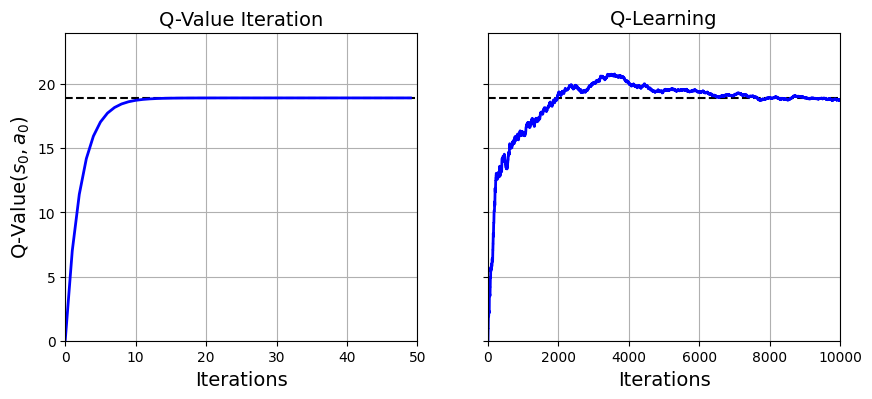

In [46]:
# extra code – this cell generates Figure 18–9

true_Q_value = history1[-1, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].set_ylabel("Q-Value$(s_0, a_0)$", fontsize=14)
axes[0].set_title("Q-Value Iteration", fontsize=14)
axes[1].set_title("Q-Learning", fontsize=14)
for ax, width, history in zip(axes, (50, 10000), (history1, history2)):
    ax.plot([0, width], [true_Q_value, true_Q_value], "k--")
    ax.plot(np.arange(width), history[:, 0, 0], "b-", linewidth=2)
    ax.set_xlabel("Iterations", fontsize=14)
    ax.axis([0, width, 0, 24])
    ax.grid(True)

plt.show()

## Algoritmo Deep Q-Learning

### Introducción

* El principal problema con Q-learning es no escala bien para problemas de tamaño mediano o largo.
* Esto es porque los valores Q son inicializados en cero y se van aprendiendo por acciones al azar.
* Para acelerar el entrenamiento es necesario tener estimaciones de valores Q sean lo mejor posible.
* DeepMind mostró que se pueden obtener estimaciones de valores Q usando redes neuronales profundas.
* La red profunda usada para estimar valores Q se llama  deep Q-network (DQN).
* Una vez estimado los valores Q con la DQN, se puede aplicar el algoritmo de Q-learning, a este algoritmo se le llama deep Q-learning.

### Entrenando una DQN

* Suponga que tenemos el valor Q aproximado calculado por la DQN para un par estado-acción dado $(s, a)$.
* Por la ecuación de Bellman, se puede aproximar los valores Q lo más cercano posible a los valores de recompensa $r$ que se obtiene cuando el agente aplica la acción $a$, en el estado $s$, más los valores de las *recompensas futuras descontadas* por jugar de forma óptima desde ese estado.
* Para obtener el valor de la suma de las *recompensas futuras descontadas*, se ejecuta DQN en el siguiente estado $s’$, para todas las acciones posibles $a’$.
* Entonces, esto obtiene un valor Q futuro aproximado para cada acción posible.
* Luego se escoge el valor Q más alto y se le aplica descuento.
* De esta manera se obtiene  una estimación de la *suma de las recompensas futuras descontadas*.
* La suma de la recompensa $r$ y la estimación del *valor futuro descontado*, da como resultado un valor Q objetivo $y(s, a)$ para la acción $a$ que se ejecuta en el estado $s$.
* Se muestra la ecuación para obtener el Q objetivo $y$:

$$
y(s, a) = r + \gamma \cdot \max_{a’} Q_\theta(s’, a’)
$$

* Con el valor Q objetivo $y$, se puede hacer el entrenamiento de la red con cualquier algoritmo de descenso del gradiente.
* Se quiere minimizar el error cuadrático entre el valor Q estimado $Q_\theta(s, a)$, y el valor Q objetivo $y(s,a)$

### Implementando una Deep Q-Learning

* En teoría se necesita un modelo de red neuronal que recibe como entrada un estado  y una acción, para que retorne un valor Q.
* En la práctica se construye un modelo de red neuronal que recibe como entrada un estado y retorna los valores Q de todas las acciones posibles.
* Para resolver el CartPole, se construye un modelo (DQN) con dos capas ocultas.

In [47]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU

input_shape = [4]  # == env.observation_space.shape
n_outputs = 2  # == env.action_space.n

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="elu", input_shape=input_shape),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(n_outputs)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* En esta DQN se escoge la acción con mayor valor Q.
* Para garantizar que el agente recorre todo en ambiente, se hace que de escoga una acción al azar con probabilidad $ϵ$.

In [48]:
def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action
    else:
        Q_values = model.predict(state[np.newaxis], verbose=0)[0]
        return Q_values.argmax()  # optimal action according to the DQN

* Se necesita un búfer de repetición.
* Este contendrá las experiencias del agente, en forma de tuplas: (obs, acción, recompensa, siguiente_obs, hecho).
* Se guarda la información en una estructura cola circular (deque).

In [49]:
from collections import deque

replay_buffer = deque(maxlen=2000)

* Se crea una función para obtener experiencias del búfer de reproducción.
* Devolverá 6 matrices NumPy: [observaciones, acciones, recompensas, próxima_obs, hechos, truncados].

In [50]:
def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
        for field_index in range(6)
    ]  # [states, actions, rewards, next_states, dones, truncateds]

* Se crea una función que utilizará el DQN para reproducir un paso y registrar su experiencia en el búfer de reproducción.

In [51]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

* Se hace la configuración de la DQN.

In [52]:
# extra code – for reproducibility, and to generate the next figure
env.reset(seed=42)
np.random.seed(42)
tf.random.set_seed(42)
rewards = []
best_score = 0

* Se crear una función que tome muestras de algunas experiencias del búfer de reproducción y realice un paso de entrenamiento.

In [58]:
batch_size = 32
discount_factor = 0.95
optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-2)
loss_fn = tf.keras.losses.MeanSquaredError()

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences
    next_Q_values = model.predict(next_states, verbose=0)
    max_next_Q_values = next_Q_values.max(axis=1)
    runs = 1.0 - (dones | truncateds)  # episode is not done or truncated
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

* Se entrena el modelo de DQN creado.

In [59]:
for episode in range(600):
    obs, info = env.reset()
    for step in range(200):
        epsilon = max(1 - episode / 500, 0.01)
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        if done or truncated:
            break

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, eps: {epsilon:.3f}",
          end="")
    rewards.append(step)
    if step >= best_score:
        best_weights = model.get_weights()
        best_score = step

    if episode > 50:
        training_step(batch_size)

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 600, Steps: 182, eps: 0.010

* Se muestran las recompensas gandas en cada episodio.

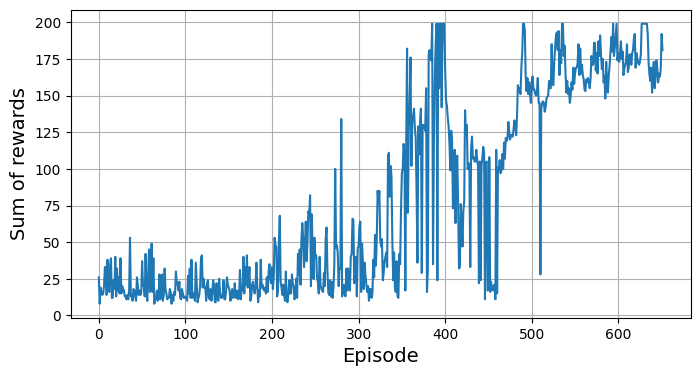

In [60]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
plt.show()

* Se muestra el modelo basado en DQN, jugando un episodio de CartPole.

In [61]:
# extra code – shows an animation of the trained DQN playing one episode
show_one_episode(epsilon_greedy_policy)